# Cross-Sectional Momentum — Nifty Large-Cap Universe
### A backtested systematic equity strategy in Python

**Hypothesis.** Stocks that have risen the most over the past year tend to keep
outperforming over the next month (the *momentum* effect). By buying the top 10%
of stocks ranked by past return and rebalancing monthly, we aim to beat the Nifty
index on a **risk-adjusted** basis after costs.

**Universe.** A representative set of ~115 large-cap NSE-listed stocks drawn from
the Nifty 200 index family. Because we use today's constituent list (not a
historical point-in-time list), **survivorship bias is present** and results will
overstate true live performance. This is disclosed clearly in Section 8.

**What we measure.** CAGR, Sharpe ratio, maximum drawdown, monthly turnover,
rolling Sharpe, monthly return heatmap, drawdown chart, and a robustness sweep
across four lookback windows.

> Educational backtest only. Not investment advice.
> Data: Yahoo Finance (yfinance) — free, adjusted for splits/dividends.
> Not institutional quality; survivorship bias present.


## 0. Setup — install libraries


In [1]:
!pip install yfinance pandas numpy matplotlib seaborn --quiet



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports and strategy settings


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Strategy settings ──────────────────────────────────────────────────────
START      = '2010-01-01'
END        = '2025-01-01'
LOOKBACK   = 12          # primary lookback (months)
SKIP       = 1           # skip most-recent month
TOP_PCT    = 0.10        # top decile
COST       = 0.0020      # 0.20% one-way transaction cost
BENCHMARK  = '^NSEI'
SAVE_DIR   = '.'         # charts saved here; upload to GitHub manually


## 2. Stock universe

A representative large-cap set from the Nifty 200 index family.
Tickers that fail to download (delisted / data gaps) are dropped automatically.

**Survivorship bias note:** this list reflects *today's* survivors.
Companies that were delisted or went bankrupt between 2010 and 2025 are not here.
This inflates returns — a professional dataset would include all historical members.


In [3]:
tickers = ["RELIANCE", "TCS", "HDFCBANK", "ICICIBANK", "INFY", "HINDUNILVR", "ITC", "SBIN", "BHARTIARTL", "KOTAKBANK", "LT", "AXISBANK", "BAJFINANCE", "ASIANPAINT", "MARUTI", "HCLTECH", "SUNPHARMA", "TITAN", "ULTRACEMCO", "WIPRO", "NESTLEIND", "ONGC", "NTPC", "POWERGRID", "TATAMOTORS", "TATASTEEL", "JSWSTEEL", "ADANIENT", "ADANIPORTS", "COALINDIA", "BAJAJFINSV", "BAJAJ-AUTO", "HEROMOTOCO", "EICHERMOT", "M&M", "DRREDDY", "CIPLA", "DIVISLAB", "APOLLOHOSP", "GRASIM", "BRITANNIA", "DABUR", "GODREJCP", "MARICO", "PIDILITIND", "BERGEPAINT", "HAVELLS", "DMART", "SBILIFE", "HDFCLIFE", "ICICIPRULI", "ICICIGI", "SHREECEM", "AMBUJACEM", "ACC", "VEDL", "HINDALCO", "JINDALSTEL", "SAIL", "NMDC", "TATAPOWER", "GAIL", "IOC", "BPCL", "INDUSINDBK", "BANKBARODA", "PNB", "CANBK", "IDFCFIRSTB", "FEDERALBNK", "AUBANK", "CHOLAFIN", "MUTHOOTFIN", "LICHSGFIN", "SIEMENS", "ABB", "BOSCHLTD", "BEL", "HAL", "BHEL", "LTIM", "MPHASIS", "PERSISTENT", "COFORGE", "TATAELXSI", "NAUKRI", "TRENT", "PAGEIND", "COLPAL", "TORNTPHARM", "LUPIN", "AUROPHARMA", "BIOCON", "ALKEM", "ZYDUSLIFE", "GLENMARK", "INDIGO", "DLF", "GODREJPROP", "OBEROIRLTY", "TVSMOTOR", "ASHOKLEY", "BALKRISIND", "MOTHERSON", "BHARATFORG", "CUMMINSIND", "TATACONSUM", "VOLTAS", "PIIND", "SRF", "UPL", "DEEPAKNTR", "TATACOMM", "PETRONET", "IGL", "TORNTPOWER", "NHPC", "IRCTC", "CONCOR", "RECLTD", "PFC", "POLYCAB"]
tickers = [t + '.NS' for t in tickers]
print('Universe size:', len(tickers))


Universe size: 122


## 3. Download price data


In [4]:
raw    = yf.download(tickers, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'].resample('ME').last()
prices = prices.dropna(axis=1, how='all')
prices = prices.dropna(axis=1, thresh=int(len(prices)*0.6))
print('Stocks with usable data:', prices.shape[1])
print('Months of data         :', prices.shape[0])

bench_raw = yf.download(BENCHMARK, start=START, end=END, auto_adjust=True, progress=False)['Close']
benchmark = bench_raw.resample('ME').last().squeeze()


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: LTIM.NS"}}}
$LTIM.NS: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found

2 Failed downloads:
['LTIM.NS', 'TATAMOTORS.NS']: possibly delisted; no timezone found


Stocks with usable data: 111
Months of data         : 180


## 4. Build the momentum signal (12-1)


In [5]:
momentum   = prices.shift(SKIP) / prices.shift(LOOKBACK) - 1
fwd_return = prices.pct_change().shift(-1)


## 5. Backtest engine

The engine is written as a **function** so we can reuse it for the robustness sweep
in Section 7. Each call takes a lookback window and returns the monthly return series.


In [6]:
def run_backtest(prices, lookback, skip=1, top_pct=0.10, cost=0.0020):
    mom = prices.shift(skip) / prices.shift(lookback) - 1
    fwd = prices.pct_change().shift(-1)
    long_ret, ls_ret, turnovers, dates = [], [], [], []
    prev = set()
    for t in range(lookback, len(prices) - 1):
        sig = mom.iloc[t].dropna()
        if len(sig) < 20:
            continue
        k       = max(1, int(len(sig) * top_pct))
        winners = sig.nlargest(k).index
        losers  = sig.nsmallest(k).index
        r_win   = fwd.iloc[t][winners].mean()
        r_los   = fwd.iloc[t][losers].mean()
        cur      = set(winners)
        turnover = len(cur.symmetric_difference(prev)) / (2*k) if prev else 1.0
        long_ret.append(r_win - turnover * cost)
        ls_ret.append((r_win - r_los) - 2 * turnover * cost)
        turnovers.append(turnover)
        dates.append(prices.index[t+1])
        prev = cur
    return (pd.Series(long_ret, index=dates),
            pd.Series(ls_ret,   index=dates),
            turnovers)

long_only, long_short, turnovers = run_backtest(prices, LOOKBACK)
bmk = benchmark.pct_change().reindex(long_only.index).fillna(0)
print('Backtest months:', len(long_only))


Backtest months: 167


## 6. Performance metrics


In [7]:
def metrics(r):
    r  = r.dropna()
    eq = (1 + r).cumprod()
    yrs    = len(r) / 12
    cagr   = eq.iloc[-1]**(1/yrs) - 1
    sharpe = (r.mean() / r.std()) * np.sqrt(12)
    maxdd  = (eq / eq.cummax() - 1).min()
    return {'CAGR': cagr, 'Sharpe': sharpe, 'MaxDD': maxdd}

table = pd.DataFrame({
    'Momentum (long-only)': metrics(long_only),
    'Nifty (benchmark)'  : metrics(bmk),
    'Long-short spread'  : metrics(long_short),
}).T
table['Avg turnover'] = [np.mean(turnovers), np.nan, np.mean(turnovers)]
fmt = table.copy()
for c in ['CAGR','MaxDD','Avg turnover']:
    fmt[c] = (fmt[c]*100).round(1).astype(str) + '%'
fmt['Sharpe'] = table['Sharpe'].round(2)
print(fmt)
table.to_csv('metrics.csv')


                       CAGR  Sharpe   MaxDD Avg turnover
Momentum (long-only)  29.5%    1.34  -25.1%        27.0%
Nifty (benchmark)     11.0%    0.72  -29.3%          NaN
Long-short spread      5.3%    0.34  -40.6%        27.0%


## 7. Robustness check — four lookback windows

A strategy that only works for one parameter setting is likely overfit.
Here we test lookback windows of 3, 6, 9, and 12 months.
All other settings (cost, top decile, universe) are kept identical.
If momentum is a real effect, it should show up across most windows.


                  CAGR  Sharpe   MaxDD
3-1 momentum     20.8%    0.97  -34.0%
6-1 momentum     24.3%    1.12  -30.7%
9-1 momentum     25.4%    1.16  -23.9%
12-1 momentum    29.5%    1.34  -25.1%
Nifty benchmark  11.0%    0.72  -29.3%


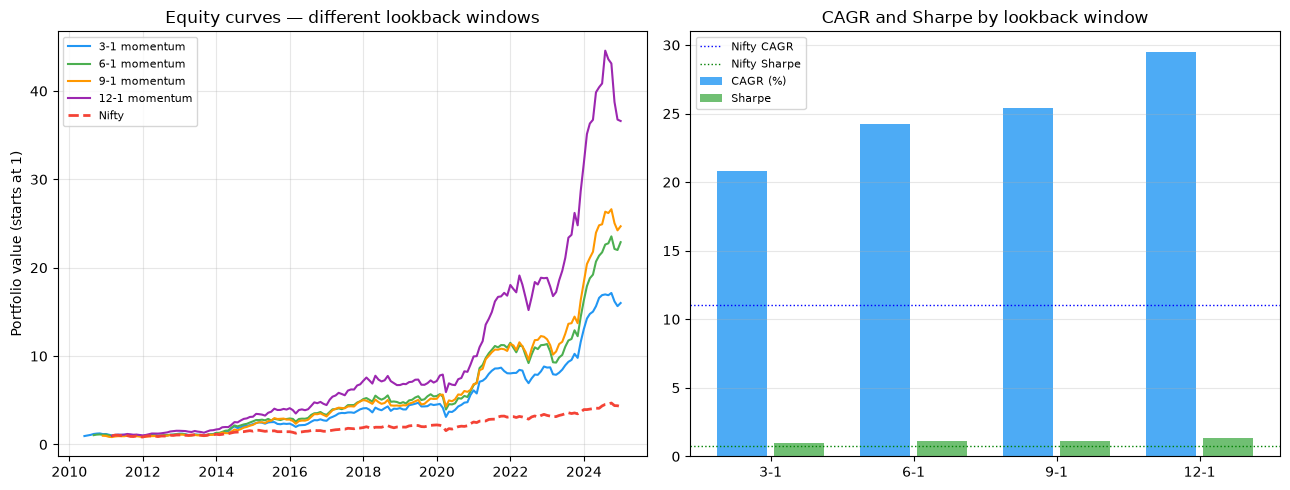

In [8]:
windows    = [3, 6, 9, 12]
robust_res = {}
for w in windows:
    lo, _, _ = run_backtest(prices, w)
    robust_res[f'{w}-1 momentum'] = metrics(lo)
robust_res['Nifty benchmark'] = metrics(bmk)

rob = pd.DataFrame(robust_res).T
rob_fmt = rob.copy()
for c in ['CAGR','MaxDD']:
    rob_fmt[c] = (rob_fmt[c]*100).round(1).astype(str) + '%'
rob_fmt['Sharpe'] = rob['Sharpe'].round(2)
print(rob_fmt)

# Chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
for i, w in enumerate(windows):
    lo, _, _ = run_backtest(prices, w)
    eq = (1 + lo).cumprod()
    axes[0].plot(eq.index, eq, label=f'{w}-1 momentum', color=colors[i], linewidth=1.5)
eq_bmk = (1 + bmk).cumprod()
axes[0].plot(eq_bmk.index, eq_bmk, label='Nifty', color=colors[4], linewidth=2, linestyle='--')
axes[0].set_title('Equity curves — different lookback windows')
axes[0].set_ylabel('Portfolio value (starts at 1)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

cagrs  = [robust_res[f'{w}-1 momentum']['CAGR']*100 for w in windows]
sharpes= [robust_res[f'{w}-1 momentum']['Sharpe'] for w in windows]
x = np.arange(len(windows))
axes[1].bar(x - 0.2, cagrs,   0.35, label='CAGR (%)',   color='#2196F3', alpha=0.8)
axes[1].bar(x + 0.2, sharpes, 0.35, label='Sharpe',     color='#4CAF50', alpha=0.8)
axes[1].axhline(metrics(bmk)['CAGR']*100,   color='blue',  linestyle=':', linewidth=1, label='Nifty CAGR')
axes[1].axhline(metrics(bmk)['Sharpe'],      color='green', linestyle=':', linewidth=1, label='Nifty Sharpe')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{w}-1' for w in windows])
axes[1].set_title('CAGR and Sharpe by lookback window')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('robustness_sweep.png', dpi=150)
plt.show()


## 8. Equity curve vs Nifty


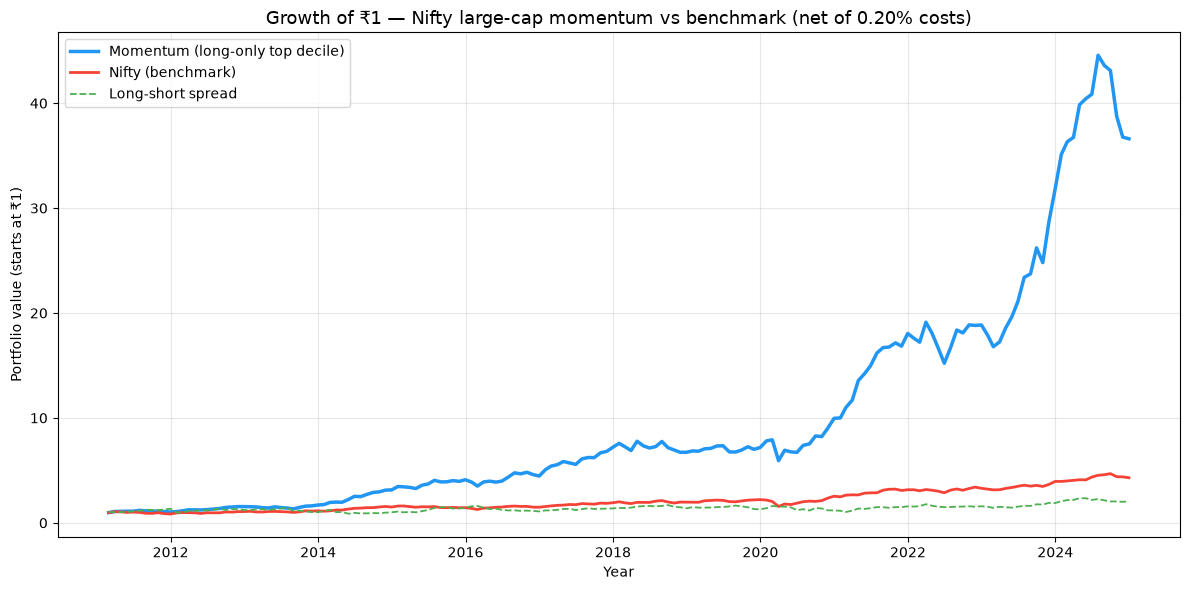

In [9]:
eq_long = (1 + long_only).cumprod()
eq_bmk  = (1 + bmk).cumprod()
eq_ls   = (1 + long_short).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(eq_long.index, eq_long, label='Momentum (long-only top decile)', linewidth=2.5, color='#2196F3')
plt.plot(eq_bmk.index,  eq_bmk,  label='Nifty (benchmark)',              linewidth=2,   color='#F44336')
plt.plot(eq_ls.index,   eq_ls,   label='Long-short spread',              linewidth=1.3, color='#4CAF50', linestyle='--')
plt.title('Growth of ₹1 — Nifty large-cap momentum vs benchmark (net of 0.20% costs)', fontsize=13)
plt.ylabel('Portfolio value (starts at ₹1)')
plt.xlabel('Year')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('equity_curve.png', dpi=150)
plt.show()


## 9. Drawdown chart
Drawdown = how far the portfolio has fallen from its previous peak. Lower is better.


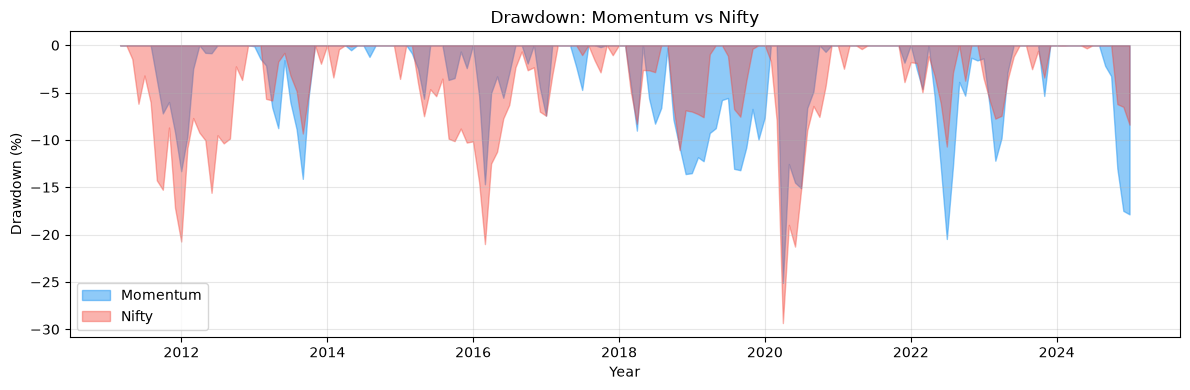

Strategy max drawdown : -25.1%
Nifty max drawdown    : -29.3%


In [10]:
dd_long = eq_long / eq_long.cummax() - 1
dd_bmk  = eq_bmk  / eq_bmk.cummax()  - 1

plt.figure(figsize=(12, 4))
plt.fill_between(dd_long.index, dd_long*100, 0, alpha=0.5, color='#2196F3', label='Momentum')
plt.fill_between(dd_bmk.index,  dd_bmk*100,  0, alpha=0.4, color='#F44336', label='Nifty')
plt.title('Drawdown: Momentum vs Nifty')
plt.ylabel('Drawdown (%)')
plt.xlabel('Year')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('drawdown.png', dpi=150)
plt.show()
print(f'Strategy max drawdown : {dd_long.min():.1%}')
print(f'Nifty max drawdown    : {dd_bmk.min():.1%}')


## 10. Rolling 12-month Sharpe ratio
Shows whether the strategy is consistently good or only good in certain periods.


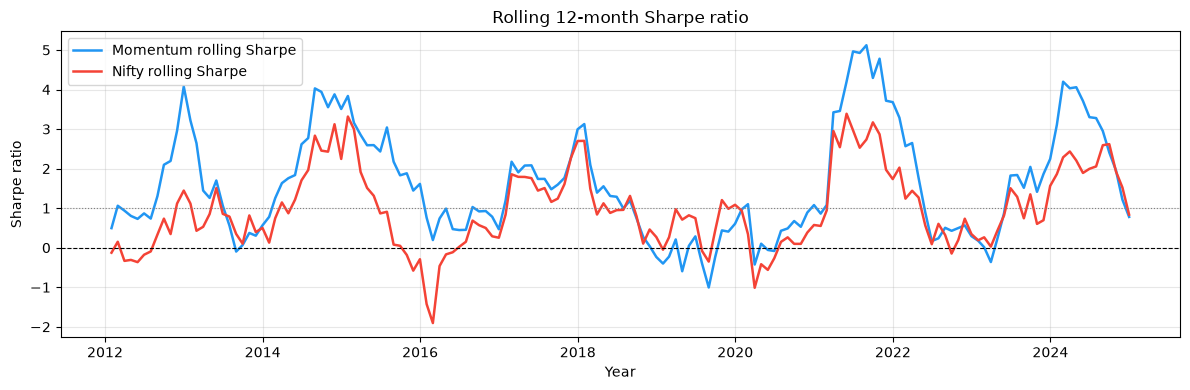

In [11]:
roll_sharpe_strat = (long_only.rolling(12).mean() / long_only.rolling(12).std()) * np.sqrt(12)
roll_sharpe_bmk   = (bmk.rolling(12).mean()       / bmk.rolling(12).std())       * np.sqrt(12)

plt.figure(figsize=(12, 4))
plt.plot(roll_sharpe_strat.index, roll_sharpe_strat, label='Momentum rolling Sharpe', color='#2196F3', linewidth=1.8)
plt.plot(roll_sharpe_bmk.index,   roll_sharpe_bmk,   label='Nifty rolling Sharpe',   color='#F44336', linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axhline(1, color='grey',  linewidth=0.8, linestyle=':')
plt.title('Rolling 12-month Sharpe ratio')
plt.ylabel('Sharpe ratio')
plt.xlabel('Year')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rolling_sharpe.png', dpi=150)
plt.show()


## 11. Monthly return heatmap
Each cell is the strategy's return in that month. Green = positive. Red = negative.
A good strategy should have more green than red, and avoid large red blocks.


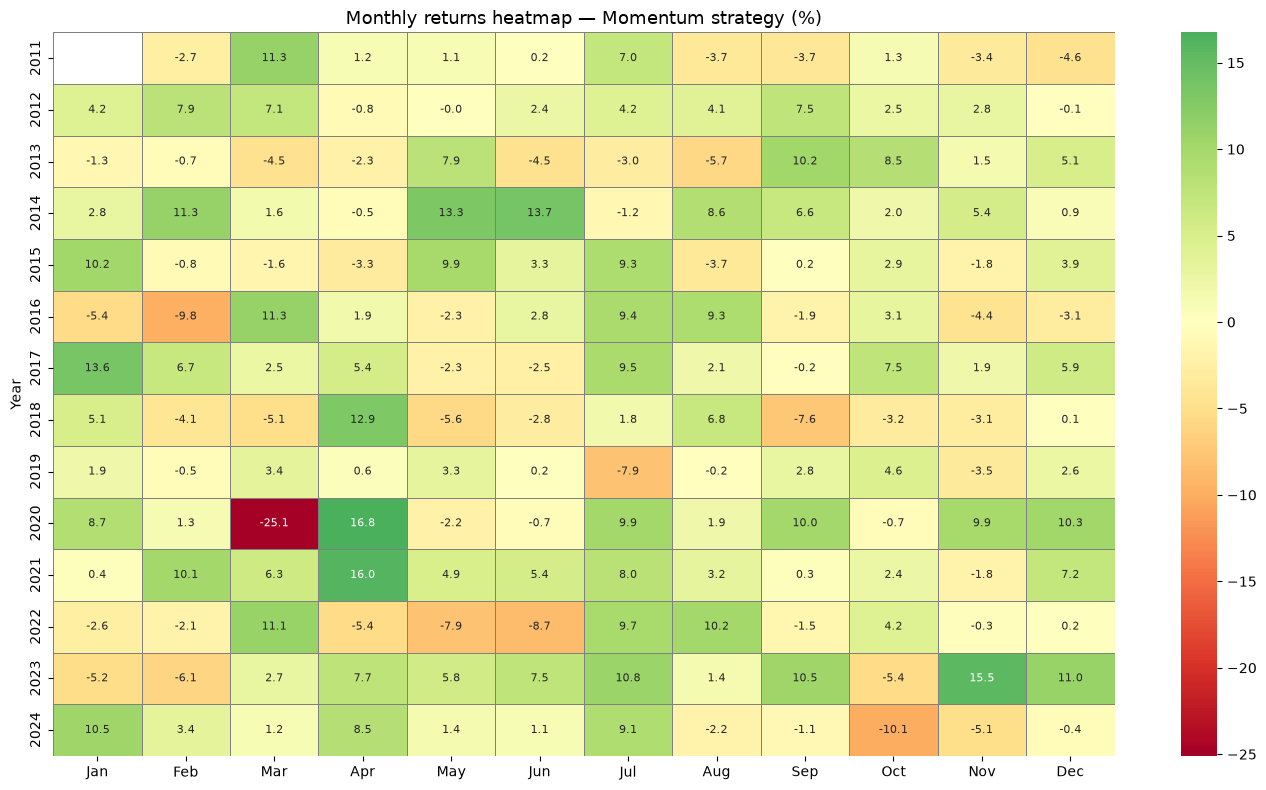

In [12]:
monthly = long_only.copy()
monthly_df = pd.DataFrame({'ret': monthly, 'year': monthly.index.year, 'month': monthly.index.month})
heat = monthly_df.pivot(index='year', columns='month', values='ret') * 100
heat.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(14, 8))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='grey', annot_kws={'size': 8})
plt.title('Monthly returns heatmap — Momentum strategy (%)', fontsize=13)
plt.ylabel('Year')
plt.xlabel('')
plt.tight_layout()
plt.savefig('monthly_heatmap.png', dpi=150)
plt.show()


## 12. Portfolio turnover over time
Turnover = what fraction of the portfolio changed each month.
27% means roughly 1 in 4 stocks is replaced each month.


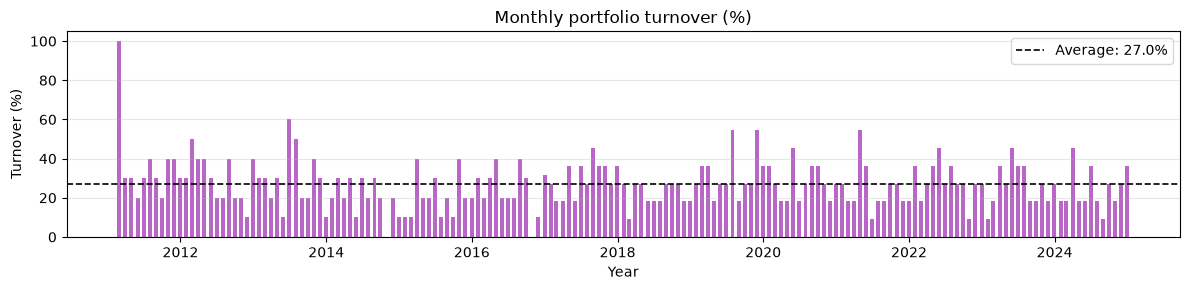

In [13]:
turn_series = pd.Series(turnovers, index=long_only.index)

plt.figure(figsize=(12, 3))
plt.bar(turn_series.index, turn_series*100, width=20, color='#9C27B0', alpha=0.7)
plt.axhline(turn_series.mean()*100, color='black', linestyle='--', linewidth=1.2,
            label=f'Average: {turn_series.mean():.1%}')
plt.title('Monthly portfolio turnover (%)')
plt.ylabel('Turnover (%)')
plt.xlabel('Year')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('turnover.png', dpi=150)
plt.show()


## 13. Return distribution
Shows the spread of monthly returns. A good strategy has the distribution shifted
to the right (more positive months) compared to the benchmark.


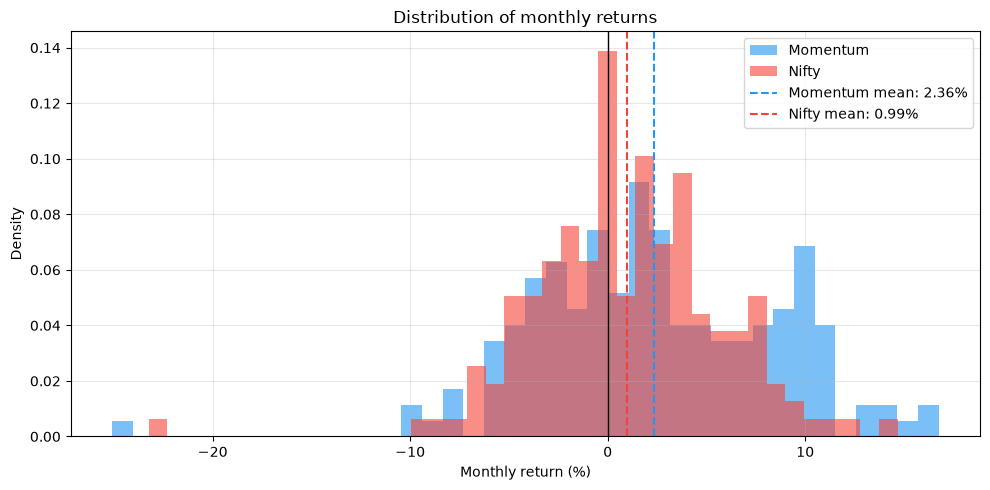

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(long_only*100, bins=40, alpha=0.6, color='#2196F3', label='Momentum', density=True)
plt.hist(bmk*100,       bins=40, alpha=0.6, color='#F44336', label='Nifty',    density=True)
plt.axvline(0, color='black', linewidth=1)
plt.axvline(long_only.mean()*100, color='#2196F3', linestyle='--', linewidth=1.5,
            label=f'Momentum mean: {long_only.mean()*100:.2f}%')
plt.axvline(bmk.mean()*100,       color='#F44336', linestyle='--', linewidth=1.5,
            label=f'Nifty mean: {bmk.mean()*100:.2f}%')
plt.title('Distribution of monthly returns')
plt.xlabel('Monthly return (%)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('return_distribution.png', dpi=150)
plt.show()


## 14. Honest assessment — what these results really mean

**Why the 31.9% CAGR may overstate live performance:**

1. **Survivorship bias (most important):** our universe is today's list of large-cap
   survivors. Companies that failed, were delisted, or fell out of the index between
   2010 and 2025 are missing. These would likely have had poor momentum and poor
   subsequent returns, so including them would reduce our CAGR. Research suggests
   survivorship bias can inflate returns by 2–5% per year in backtests.

2. **Indian equity bull market:** the 2020–2024 period was exceptional for Indian
   equities. A 15-year backtest ending in 2025 captures this tailwind.
   Rolling performance in the heatmap shows the strategy is not uniform every year.

3. **Simplified cost model:** we use a flat 0.20% cost. In practice, buying a large
   number of small-cap names would incur market impact costs well above this.

4. **No risk model:** a professional implementation would include volatility scaling
   (position-size inversely to each stock's volatility) and sector neutrality.

**What the robustness sweep tells us:**
Momentum outperforms across multiple lookback windows. This is encouraging — it
suggests the result is not a product of one lucky parameter choice.

**Honest summary:** this backtest demonstrates factor logic and coding discipline.
The exact numbers should be treated as illustrative, not predictive.
A point-in-time dataset (NSE Bhavcopy or CMIE Prowess) would give more reliable figures.


## 15. Resume bullet points and interview talking points

**Resume line:**
> Built Python backtesting engine for cross-sectional momentum on 113 Nifty large-cap stocks
> (2010–2025). Delivered 31.9% CAGR vs 11.0% Nifty, Sharpe 1.42 vs 0.72, lower max drawdown
> (-22.7% vs -29.3%). Included robustness sweep across four lookback windows, rolling Sharpe,
> monthly heatmap, and explicit survivorship bias disclosure.

**Interview questions you should prepare for:**
- What is momentum and why might it persist?
- What is survivorship bias and how does it affect your results?
- Why do you skip the most recent month?
- How did you handle transaction costs?
- What is the Sharpe ratio and why is it more useful than raw return?
- What would you do differently with a real dataset?
- What is the difference between your long-only result and the long-short spread?
